In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

## We want to use the Ames Housing Data Set to assess how much the quality of a home's kitchen affect's the home's sale price

In [2]:
# Load Ames dataset

file_path = 'Resources/data/AmesHousing.csv'
df = pd.read_csv(file_path)
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## We need to convert the Kitchen Quality codes into numeric values. Ex (Excellent) becomes 5, Gd (Good) becomes 4, etc. We use the map function to accomplish this.

In [3]:
# Mapping Kitchen Qual to numerical values
kitchen_qual_mapping = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}
df["Kitchen Qual"] = df["Kitchen Qual"].map(kitchen_qual_mapping)

print(df["Kitchen Qual"].unique())

[3 4 5 2 1]


## First we'll simply calculate the correlation between Sales Price and Kitchen Quality

In [4]:
# Check correlation with sale price
correlation = df[["Kitchen Qual", "SalePrice"]].corr()
print("Kitchen Quality correlation with Sale Price: \n", correlation)


Kitchen Quality correlation with Sale Price: 
               Kitchen Qual  SalePrice
Kitchen Qual      1.000000   0.672914
SalePrice         0.672914   1.000000


## A 0.67 correlation shows a strong relationship between kitchen quality and sales price. However, there are definitely other significant factors. 
## Let's build a Random Forest model to assess realtive feature strength. We choose Random Forest because we are assessing complex relationships with multiple predictors, not simple linear regression.

In [5]:
# Selecting features for Sale Price prediction model
features = ["Overall Qual", "Gr Liv Area", "Garage Cars", "Full Bath", "Half Bath", "TotRms AbvGrd", "Year Built", "Kitchen Qual"]

X = df[features]
y = df["SalePrice"]

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [7]:
# Get feature importances, print, then plot

feature_importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importance Scores:")
for feature, importance in feature_importance.items():
    print(f"{feature}: {importance:.3f}")



Feature Importance Scores:
Overall Qual: 0.624
Gr Liv Area: 0.187
Year Built: 0.062
Garage Cars: 0.040
Full Bath: 0.035
TotRms AbvGrd: 0.022
Kitchen Qual: 0.021
Half Bath: 0.011


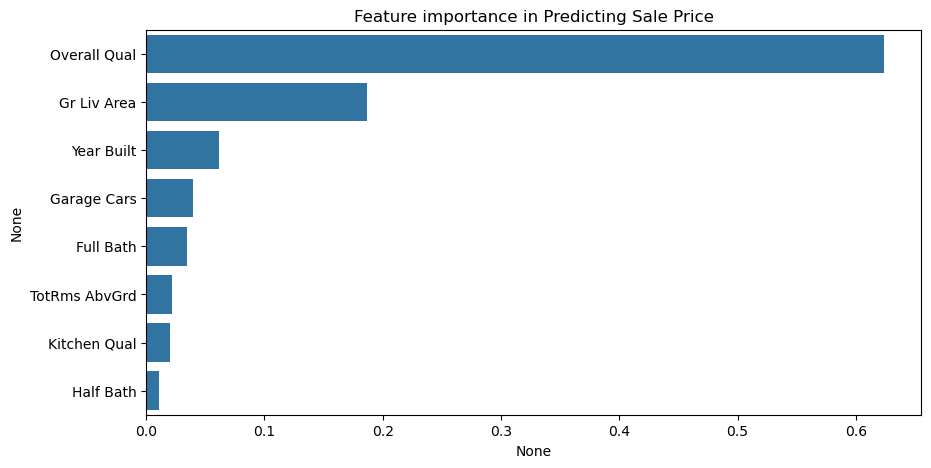

In [8]:
# Plot feature importances
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Feature importance in Predicting Sale Price")
plt.show()

In [9]:
# Evaluate model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2 score: {r2:.3f}")

R2 score: 0.840


## The model has a strong r2 score, indicating it is effective in predicting Sale Price.

## However, Kitchen quality takes a backseat to many other features as a driver of Sales Price. So it has likely has an affect on the Sale Price but not as much as several other features. 